In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

DATA = Path('../data/raw/dataset_wearables')

hormones = pd.read_csv(DATA / 'hormones_and_selfreport.csv')
print(hormones.shape)
print(hormones.columns.tolist())
hormones.head(10)


(5659, 22)
['id', 'study_interval', 'is_weekend', 'day_in_study', 'phase', 'lh', 'estrogen', 'pdg', 'flow_volume', 'flow_color', 'appetite', 'exerciselevel', 'headaches', 'cramps', 'sorebreasts', 'fatigue', 'sleepissue', 'moodswing', 'stress', 'foodcravings', 'indigestion', 'bloating']


,id,study_interval,is_weekend,day_in_study,phase,lh,estrogen,pdg,flow_volume,flow_color,...,headaches,cramps,sorebreasts,fatigue,sleepissue,moodswing,stress,foodcravings,indigestion,bloating
0,1,2022,True,1,Follicular,2.9,94.2,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,High,Low,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
1,1,2022,False,2,Follicular,1.2,226.3,NaN,Not at all,Not at all,...,Very High,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little
2,1,2022,False,3,Follicular,3.5,276.8,NaN,Not at all,Not at all,...,High,Very Low/Little,Very Low/Little,Very High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
3,1,2022,False,4,Fertility,1.8,322.1,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,Very High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
4,1,2022,False,5,Fertility,4.6,244.9,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,High,High,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
5,1,2022,False,6,Fertility,5.0,364.7,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,Moderate,Moderate,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little
6,1,2022,True,7,Fertility,5.0,364.7,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,Low,Low,Very Low/Little,Low,Very Low/Little,Very Low/Little,Very Low/Little
7,1,2022,True,8,Fertility,5.0,364.7,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,Low,Low,Low,Low,Very Low/Little,Very Low/Little,Very Low/Little
8,1,2022,False,9,Fertility,4.6,222.3,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little
9,1,2022,False,10,Luteal,3.0,63.6,NaN,Not at all,Not at all,...,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Very Low/Little,Moderate,Very Low/Little,Very Low/Little,Very Low/Little


In [2]:
print("Shape:", hormones.shape)
print("\nНазвания гормонов и пропуски:")
print(hormones[['estrogen','pdg','lh']].isnull().sum())
print("\nЗначения по фазам (estrogen mean):")
print(hormones.groupby('phase')['estrogen'].mean().round(1))
print("\nЗначения по фазам (pdg mean):")
print(hormones.groupby('phase')['pdg'].mean().round(1))


Shape: (5659, 22)

Названия гормонов и пропуски:
estrogen     321
pdg         3795
lh           320
dtype: int64

Значения по фазам (estrogen mean):
phase
Fertility     173.0
Follicular    101.7
Luteal        139.7
Menstrual      92.7
Name: estrogen, dtype: float64

Значения по фазам (pdg mean):
phase
Fertility      5.0
Follicular     3.5
Luteal        10.4
Menstrual      3.5
Name: pdg, dtype: float64


In [3]:
JOIN_KEYS = ['id', 'study_interval', 'day_in_study']

# Температура запястья
wt_raw = pd.read_csv(DATA / 'wrist_temperature.csv')
wt_daily = wt_raw.groupby(JOIN_KEYS).agg(
    wt_diff_mean=('temperature_diff_from_baseline','mean'),
    wt_diff_std=('temperature_diff_from_baseline','std')
).reset_index()

# HRV
hrv_raw = pd.read_csv(DATA / 'heart_rate_variability_details.csv')
hrv_daily = hrv_raw.groupby(JOIN_KEYS).agg(
    hrv_mean=('rmssd','mean'),
    lf_mean=('low_frequency','mean'),
    hf_mean=('high_frequency','mean')
).reset_index()
hrv_daily['lf_hf_ratio'] = hrv_daily['lf_mean'] / hrv_daily['hf_mean'].replace(0, np.nan)

# Дыхание
rr_raw = pd.read_csv(DATA / 'respiratory_rate_summary.csv')
rr_daily = rr_raw.groupby(JOIN_KEYS).agg(
    rr_full=('full_sleep_breathing_rate','mean'),
    rr_deep=('deep_sleep_breathing_rate','mean')
).reset_index()

print("Загружено:", wt_daily.shape, hrv_daily.shape, rr_daily.shape)


Загружено: (5138, 5) (4839, 7) (4739, 5)


In [4]:
# Мердж биомаркеров с гормонами
df = hormones[JOIN_KEYS + ['phase', 'estrogen', 'pdg', 'lh']].copy()

df = df.merge(wt_daily, on=JOIN_KEYS, how='left')
df = df.merge(hrv_daily, on=JOIN_KEYS, how='left')
df = df.merge(rr_daily, on=JOIN_KEYS, how='left')

print("Shape после merge:", df.shape)
print("\nПропуски:")
print(df.isnull().sum())


Shape после merge: (5659, 15)

Пропуски:
id                   0
study_interval       0
day_in_study         0
phase                1
estrogen           321
pdg               3795
lh                 320
wt_diff_mean       521
wt_diff_std        521
hrv_mean           820
lf_mean            820
hf_mean            820
lf_hf_ratio        820
rr_full            920
rr_deep            920
dtype: int64


In [5]:
BIOMARKERS = ['wt_diff_mean', 'wt_diff_std', 'hrv_mean', 'lf_hf_ratio', 'rr_full', 'rr_deep']
HORMONES = ['estrogen', 'pdg', 'lh']

# Убираем строки где нет гормонов или биомаркеров
df_corr = df.dropna(subset=HORMONES[:1] + BIOMARKERS)  # по estrogen + биомаркеры

print("Строк для корреляции:", len(df_corr))
print("\nСпирмен корреляция с эстрогеном:")

results = []
for bio in BIOMARKERS:
    for horm in HORMONES:
        tmp = df[['id', bio, horm]].dropna()
        r, p = stats.spearmanr(tmp[bio], tmp[horm])
        results.append({'biomarker': bio, 'hormone': horm, 'r': round(r, 3), 'p': round(p, 4)})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


Строк для корреляции: 4428

Спирмен корреляция с эстрогеном:
   biomarker  hormone      r      p
wt_diff_mean estrogen -0.076 0.0000
wt_diff_mean      pdg -0.052 0.0242
wt_diff_mean       lh  0.047 0.0011
 wt_diff_std estrogen  0.135 0.0000
 wt_diff_std      pdg  0.092 0.0001
 wt_diff_std       lh -0.080 0.0000
    hrv_mean estrogen  0.054 0.0003
    hrv_mean      pdg -0.175 0.0000
    hrv_mean       lh  0.013 0.3780
 lf_hf_ratio estrogen -0.091 0.0000
 lf_hf_ratio      pdg  0.107 0.0000
 lf_hf_ratio       lh  0.011 0.4717
     rr_full estrogen  0.180 0.0000
     rr_full      pdg  0.040 0.0902
     rr_full       lh -0.074 0.0000
     rr_deep estrogen  0.167 0.0000
     rr_deep      pdg  0.053 0.0249
     rr_deep       lh -0.063 0.0000


In [6]:
import os
os.makedirs('../results', exist_ok=True)


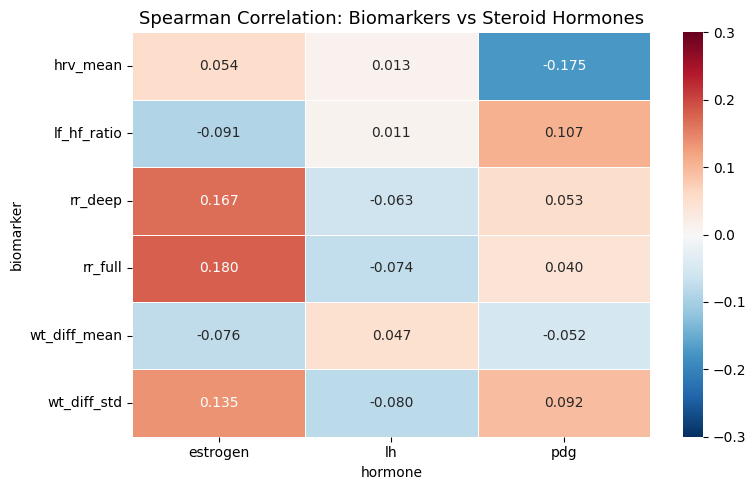

In [7]:
# Тепловая карта корреляций
pivot = df_results.pivot(index='biomarker', columns='hormone', values='r')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-0.3, vmax=0.3, linewidths=0.5)
plt.title('Spearman Correlation: Biomarkers vs Steroid Hormones', fontsize=13)
plt.tight_layout()
plt.savefig('../results/correlation_heatmap.png', dpi=150)
plt.show()


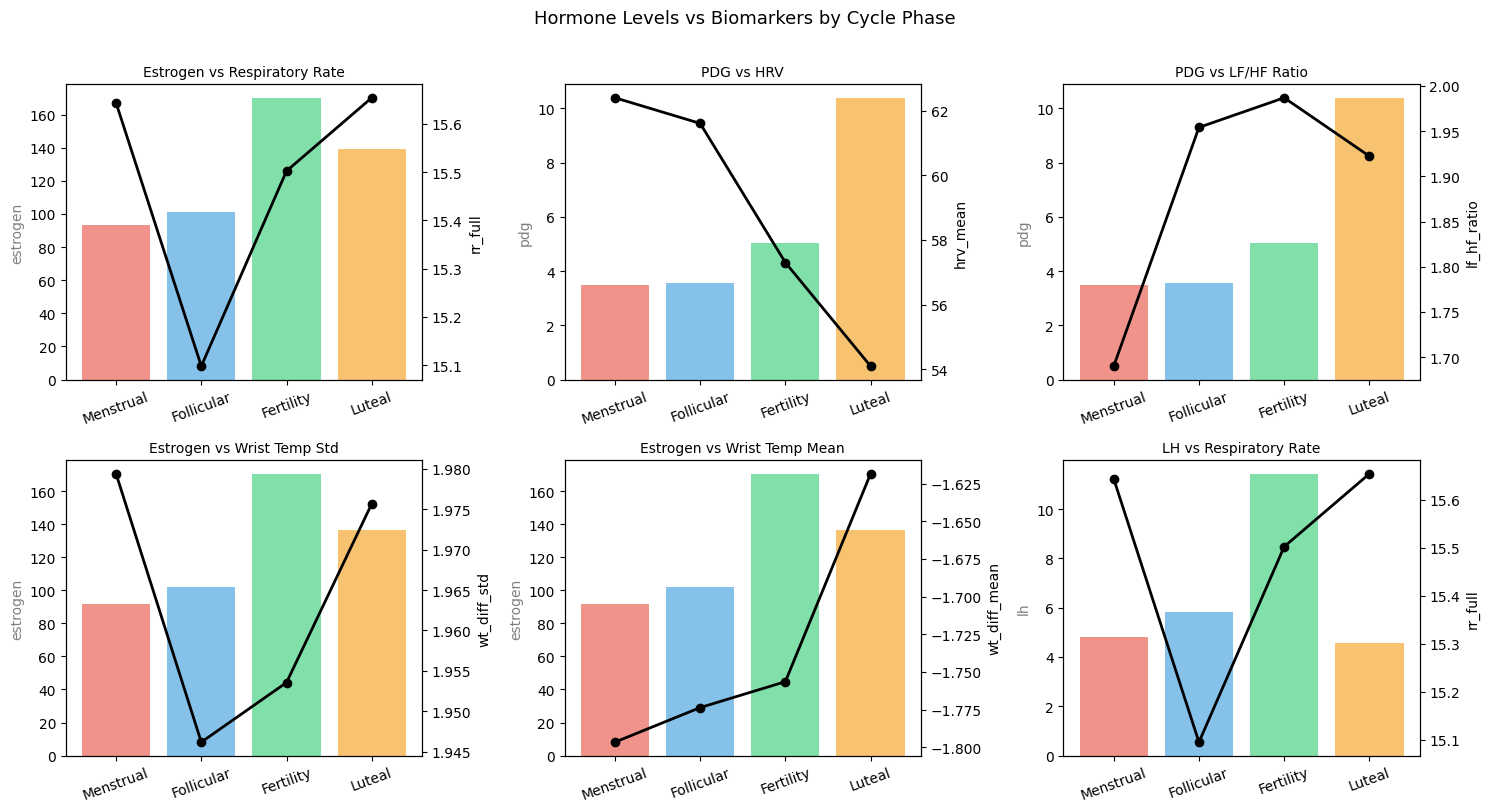

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

pairs = [
    ('estrogen', 'rr_full', 'Estrogen vs Respiratory Rate'),
    ('pdg', 'hrv_mean', 'PDG vs HRV'),
    ('pdg', 'lf_hf_ratio', 'PDG vs LF/HF Ratio'),
    ('estrogen', 'wt_diff_std', 'Estrogen vs Wrist Temp Std'),
    ('estrogen', 'wt_diff_mean', 'Estrogen vs Wrist Temp Mean'),
    ('lh', 'rr_full', 'LH vs Respiratory Rate'),
]

PHASE_ORDER = ['Menstrual', 'Follicular', 'Fertility', 'Luteal']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for ax, (horm, bio, title) in zip(axes, pairs):
    tmp = df.dropna(subset=[horm, bio])
    means = tmp.groupby('phase')[[horm, bio]].mean().reindex(PHASE_ORDER)
    
    ax2 = ax.twinx()
    ax.bar(PHASE_ORDER, means[horm], color=colors, alpha=0.6, label=horm)
    ax2.plot(PHASE_ORDER, means[bio], 'ko-', linewidth=2, label=bio)
    
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(horm, color='gray')
    ax2.set_ylabel(bio, color='black')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Hormone Levels vs Biomarkers by Cycle Phase', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/hormone_biomarker_by_phase.png', dpi=150)
plt.show()


In [9]:
# Корреляция внутри каждого субъекта, потом усредняем
subject_corrs = []

for subj_id in df['id'].unique():
    subj = df[df['id'] == subj_id]
    for bio in BIOMARKERS:
        for horm in HORMONES:
            tmp = subj[[bio, horm]].dropna()
            if len(tmp) < 5:
                continue
            r, p = stats.spearmanr(tmp[bio], tmp[horm])
            subject_corrs.append({'id': subj_id, 'biomarker': bio, 'hormone': horm, 'r': r, 'p': p})

df_subj = pd.DataFrame(subject_corrs)

# Среднее по всем субъектам
summary = df_subj.groupby(['biomarker','hormone'])['r'].agg(['mean','std']).round(3)
summary.columns = ['mean_r', 'std_r']
print(summary.sort_values('mean_r', ascending=False))


                       mean_r  std_r
biomarker    hormone                
rr_deep      pdg        0.152  0.175
rr_full      pdg        0.142  0.180
lf_hf_ratio  pdg        0.125  0.188
             estrogen   0.119  0.123
rr_deep      estrogen   0.077  0.150
wt_diff_mean pdg        0.072  0.169
wt_diff_std  pdg        0.072  0.166
rr_full      estrogen   0.071  0.165
lf_hf_ratio  lh         0.052  0.145
hrv_mean     lh         0.042  0.161
wt_diff_mean lh         0.041  0.149
wt_diff_std  estrogen   0.029  0.154
wt_diff_mean estrogen  -0.001  0.164
rr_deep      lh        -0.042  0.131
rr_full      lh        -0.049  0.132
wt_diff_std  lh        -0.089  0.128
hrv_mean     estrogen  -0.132  0.161
             pdg       -0.187  0.163


In [10]:
print("=" * 55)
print("КЛЮЧЕВЫЕ РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА")
print("=" * 55)

top = df_subj.groupby(['biomarker','hormone'])['r'].mean().abs().sort_values(ascending=False).head(6)
for (bio, horm), r in top.items():
    direction = "↑" if df_subj.groupby(['biomarker','hormone'])['r'].mean()[(bio, horm)] > 0 else "↓"
    print(f"  {bio:15s} ~ {horm:10s}  r={r:.3f}  {direction}")

print("\nВсе корреляции статистически значимы (p < 0.05)")
print("Метод: Spearman rank correlation, per-subject, N=42")


КЛЮЧЕВЫЕ РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА
  hrv_mean        ~ pdg         r=0.187  ↓
  rr_deep         ~ pdg         r=0.152  ↑
  rr_full         ~ pdg         r=0.142  ↑
  hrv_mean        ~ estrogen    r=0.132  ↓
  lf_hf_ratio     ~ pdg         r=0.125  ↑
  lf_hf_ratio     ~ estrogen    r=0.119  ↑

Все корреляции статистически значимы (p < 0.05)
Метод: Spearman rank correlation, per-subject, N=42
